<a href="https://colab.research.google.com/github/muchammadwr/bank-segmentation-customers/blob/main/clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [15]:
!pip install -U scikit-learn

In [16]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [17]:
# Library's version
print("Python:", sys.version)
print("Scikit-learn:", sklearn.__version__)
print("Pandas:", pd.__version__)
print("Joblib:", joblib.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Scikit-learn: 1.9.1
Pandas: 2.2.3
Joblib: 1.6.0


## Data Understanding

In [18]:
# Load data
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'

In [19]:
df = pd.read_csv(url)
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


In [20]:
# Data Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [21]:
# Data Descriptive Statistics
df.describe(include='all')

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
count,2508,2516,2511.000000,2509,2507,2507,2507,2517,2514,2510,2519.000000,2514,2511.000000,2516.000000,2510.000000,2513
unique,2484,495,NaN,2485,2,43,681,591,100,3,NaN,4,NaN,NaN,NaN,360
top,TX002326,AC00362,NaN,2023-12-22 16:42:33,Debit,Fort Worth,D000697,200.136.146.93,M026,Branch,NaN,Student,NaN,NaN,NaN,2024-11-04 8:09:17
freq,2,12,NaN,2,1942,71,9,12,46,868,NaN,657,NaN,NaN,NaN,18
mean,NaN,NaN,297.656468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.678444,NaN,119.422939,1.121622,5113.438124,NaN
std,NaN,NaN,292.230367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.837359,NaN,70.078513,0.594469,3897.975861,NaN
min,NaN,NaN,0.260000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,NaN
25%,NaN,NaN,81.310000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.727500,NaN
50%,NaN,NaN,211.360000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,112.000000,1.000000,4734.110000,NaN
75%,NaN,NaN,413.105000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7672.687500,NaN


## Cleaning Data

### Missing

In [22]:
df.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
PreviousTransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [23]:
# Handle mising values
df.dropna(inplace=True)
df.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
PreviousTransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


### Duplicates

In [24]:
df.duplicated().sum()

np.int64(21)

In [25]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

### Categorical

In [26]:
categorical_cols = df.select_dtypes(include='object')
categorical_cols.describe()

,TransactionID,AccountID,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerOccupation,TransactionDate
count,2135,2135,2135,2135,2135,2135,2135,2135,2135,2135,2135
unique,2135,493,2135,2,43,668,586,100,3,4,360
top,TX000592,AC00363,2023-05-15 16:19:14,Debit,Fort Worth,D000451,200.136.146.93,M026,Branch,Student,2024-11-04 8:09:17
freq,1,11,1,1651,62,9,10,43,744,561,15


### Numerical

In [27]:
numerical_cols = df.select_dtypes(include='number')
numerical_cols.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2135.000000,2135.000000,2135.000000,2135.000000,2135.000000
mean,298.096178,44.622951,120.152693,1.117564,5093.583789
std,290.962542,17.835201,70.862964,0.578225,3919.681355
min,0.260000,18.000000,10.000000,1.000000,102.200000
25%,83.045000,27.000000,63.000000,1.000000,1482.350000
50%,213.330000,45.000000,113.000000,1.000000,4638.370000
75%,414.630000,59.000000,162.000000,1.000000,7696.920000
max,1831.020000,80.000000,300.000000,5.000000,14977.990000


## Exploratory Data Analysis

### Categorical

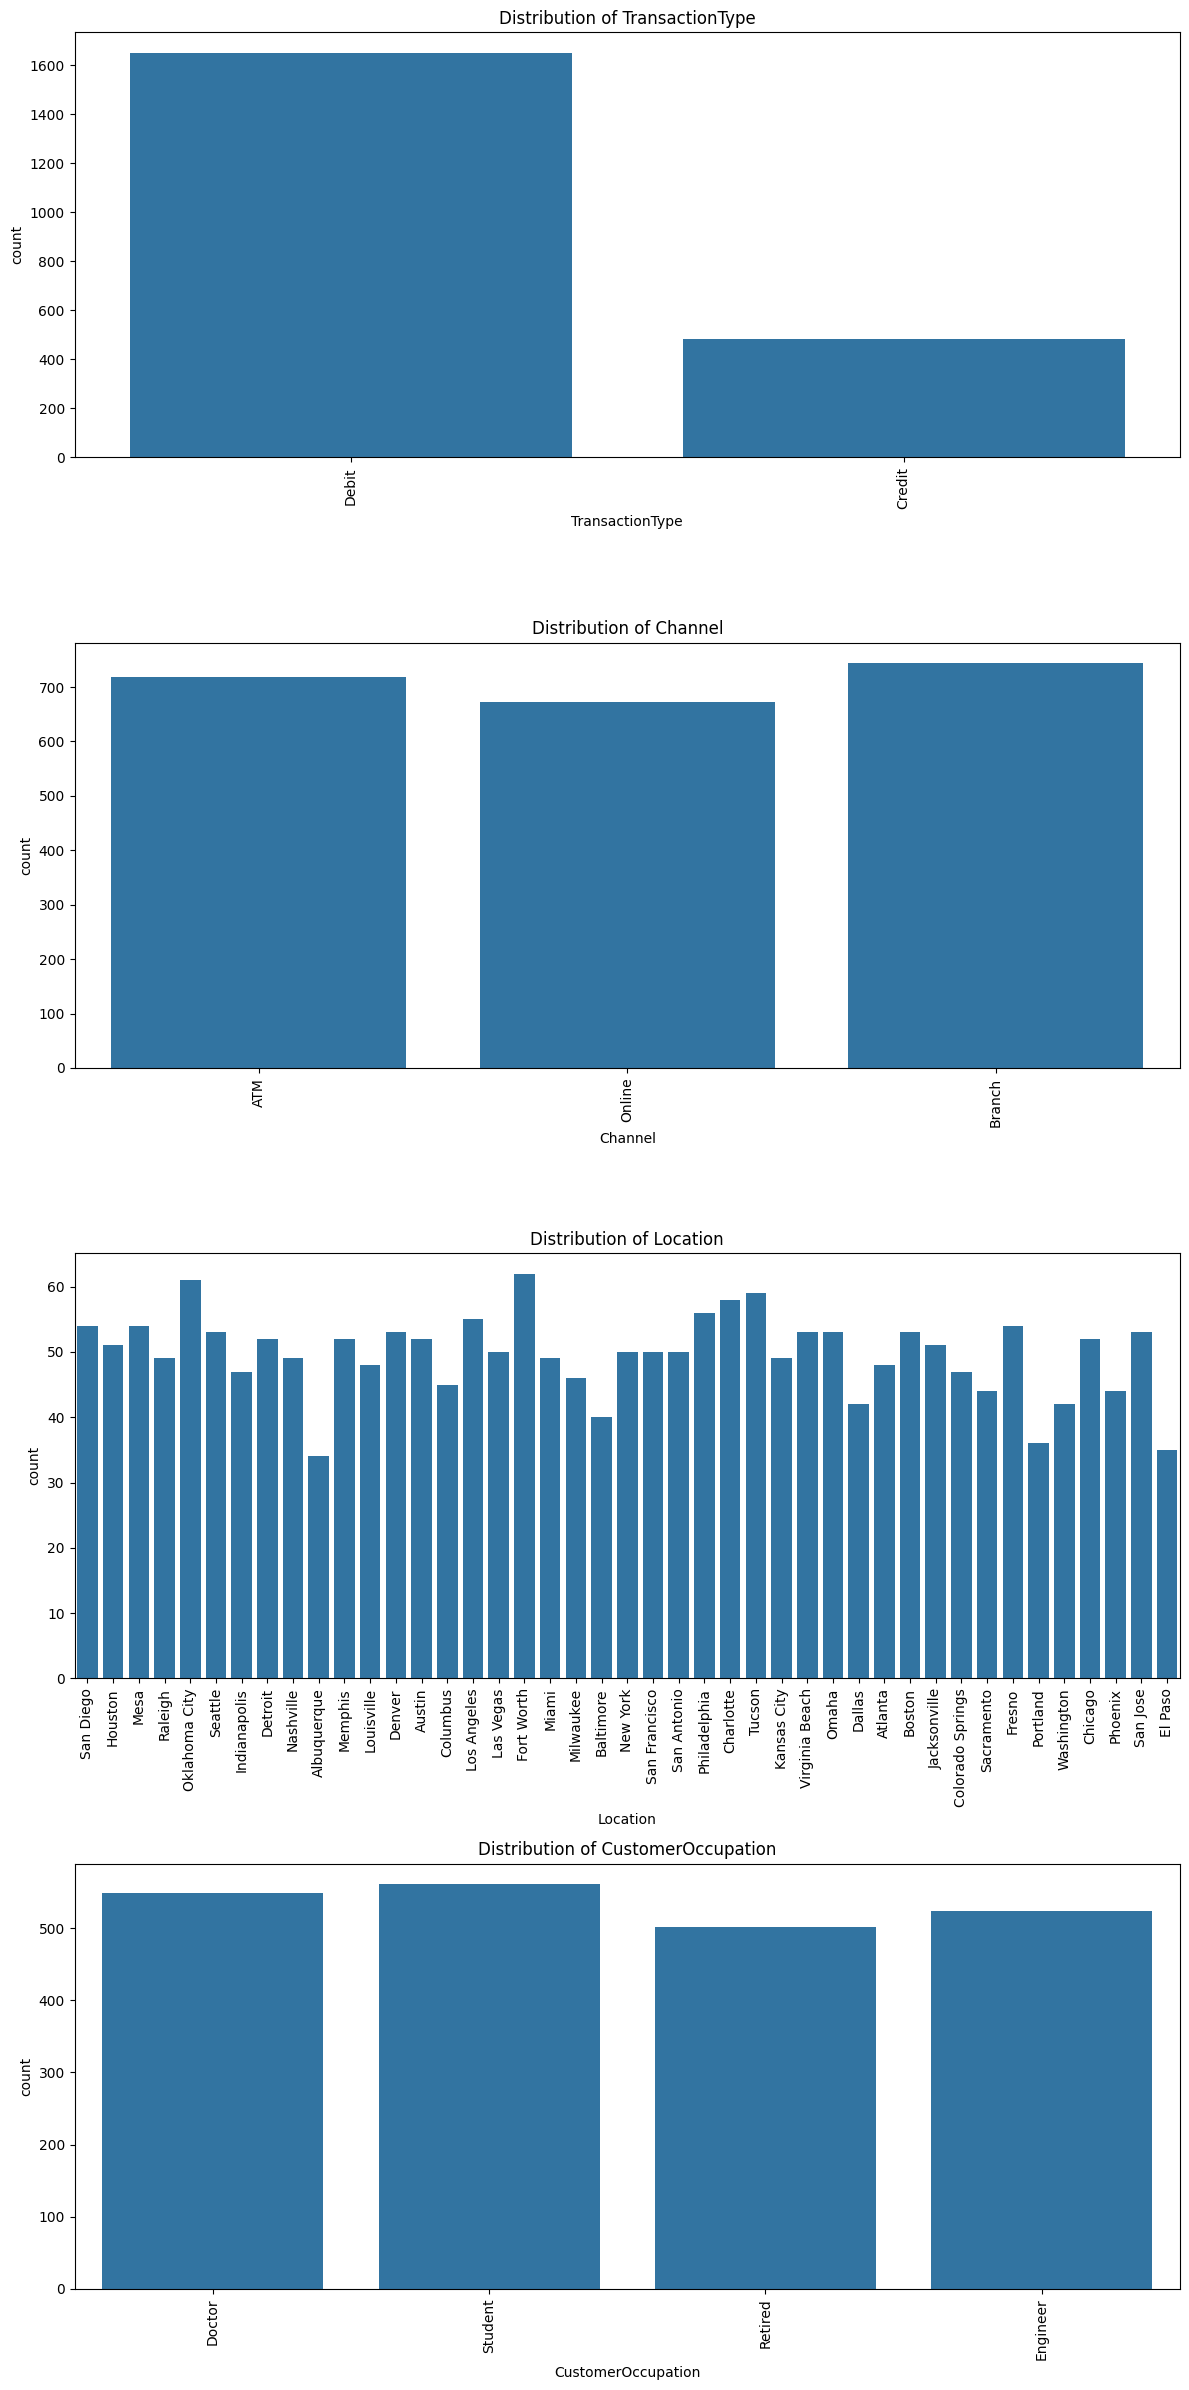

In [28]:
# Distribution Categorical
categorical_cols = [
    'TransactionType',
    'Channel',
    'Location',
    'CustomerOccupation'
    ]

fig, axes = plt.subplots(
    nrows=len(categorical_cols),
    ncols=1,
    figsize=(12, 24),
)

for index, column in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=column,
        ax=axes[index],
    )

    axes[index].set_title(
        f"Distribution of {column}"
    )

    axes[index].tick_params(
        axis="x",
        rotation=90,
    )

plt.tight_layout()
plt.show()

In [29]:
# New Category

col_to_bin = 'CustomerAge'
new_col_name = 'AgeGroupBin'

bin_labels = ['rendah', 'sedang', 'tinggi']

# Gunakan 'pd.qcut' untuk membagi data menjadi 3 kelompok
df[new_col_name] = pd.qcut(df[col_to_bin], q=3, labels=bin_labels, duplicates='drop')

In [30]:
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,AgeGroupBin
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08,tinggi
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35,tinggi
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04,rendah
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06,rendah
5,TX000006,AC00393,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 8:06:36,rendah


### Numerical

In [31]:
numerical_cols = df.select_dtypes(include='number').columns

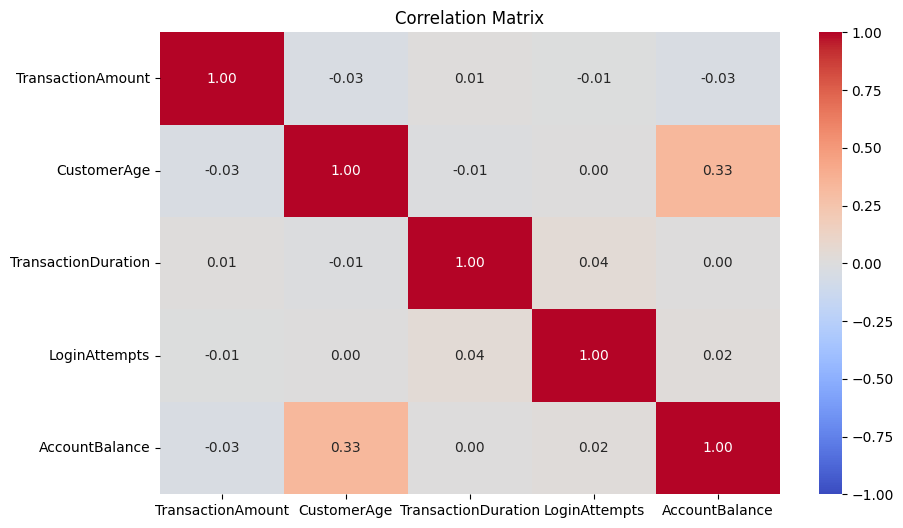

In [32]:
# Correlation
numerical_cols = df.select_dtypes(include=['number']).columns
correlation = df[numerical_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
plt.show()


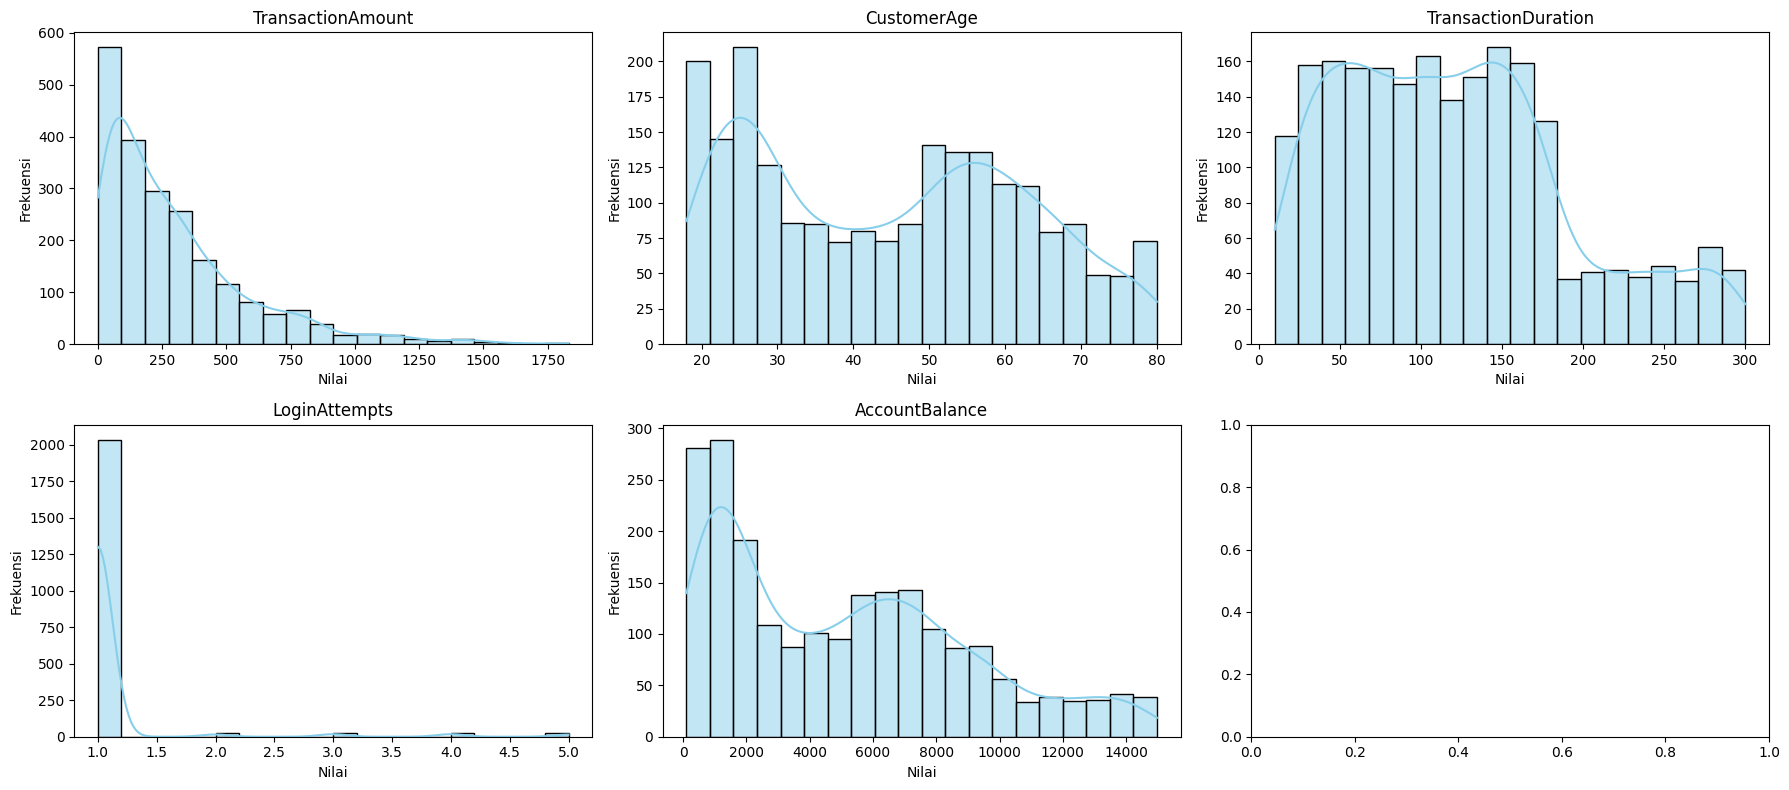

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):


    sns.histplot(df[column], bins=20, kde=True, color='skyblue', ax = axes[i])

    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")


plt.tight_layout()
plt.show()

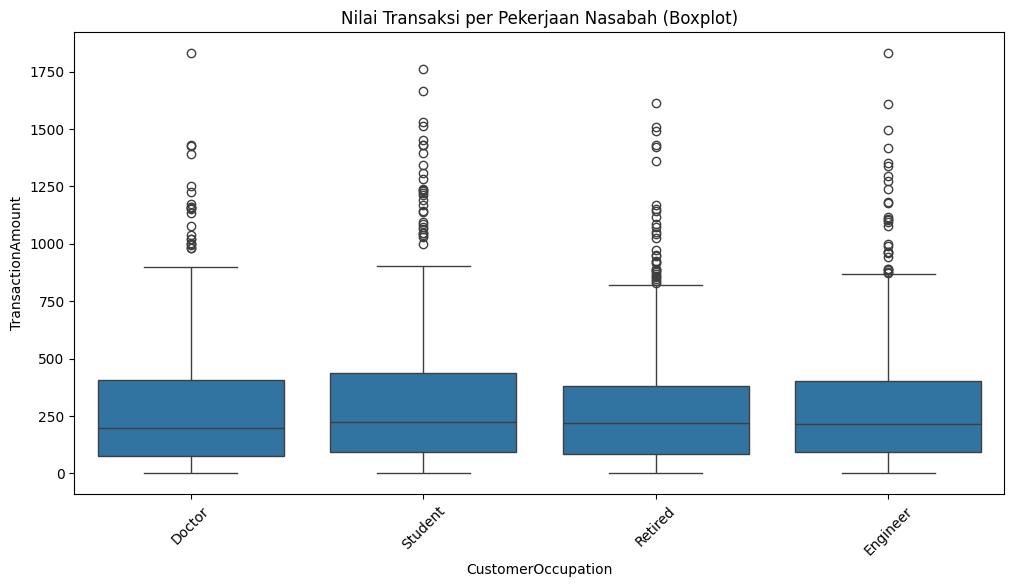

In [34]:
plt.figure(figsize=(12, 6))

sns.boxplot(x="CustomerOccupation", y="TransactionAmount", data=df)

plt.title("Nilai Transaksi per Pekerjaan Nasabah (Boxplot)")

plt.xticks(rotation=45)

plt.show()

## Preprocessing

### Categorical

In [35]:
cols_to_drop = [col for col in df.columns if
                "id" in col.lower() or
                'ip' in col.lower() or
                'date' in col.lower()]


df = df.drop(columns=cols_to_drop)
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroupBin
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,tinggi
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,tinggi
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,rendah
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,rendah
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,rendah


### Numerical

In [36]:
# Handling Outlier Data

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,1945.000000,1945.000000,1945.000000,1945.0,1945.000000
mean,256.838278,44.693059,119.225193,1.0,5100.811913
std,218.370197,17.743453,70.600647,0.0,3907.153333
min,0.260000,18.000000,10.000000,1.0,102.200000
25%,78.920000,27.000000,63.000000,1.0,1488.650000
50%,199.700000,45.000000,111.000000,1.0,4693.600000
75%,374.500000,59.000000,162.000000,1.0,7659.990000
max,903.190000,80.000000,300.000000,1.0,14977.990000


## Modelling